# STATSFORECAST Library

https://nixtlaverse.nixtla.io

https://nixtlaverse.nixtla.io/statsforecast/docs/how-to-guides/automatic_forecasting.html

In [64]:
pip install statsforecast

Note: you may need to restart the kernel to use updated packages.


In [65]:
from statsforecast import StatsForecast
from statsforecast.models import MSTL, AutoARIMA, AutoETS, AutoTheta, AutoCES

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os

In [66]:
df = pd.read_csv('../scr/data/cleaned_rat_sightings_data/daily_borough_rs.csv')
df['created_date'] = pd.to_datetime(df['created_date']) 
df = df[df['borough']=='MANHATTAN']
full_dates = pd.date_range('2020-01-01', '2025-12-31', freq='D')
full_index = pd.MultiIndex.from_product([['MANHATTAN'], full_dates], names=['borough', 'created_date'])
df = df.set_index(['borough', 'created_date']).reindex(full_index).fillna({'count': 0}).reset_index()
df['count'] = df['count'].astype(int)
df.drop(columns=['borough'], inplace=True)
df = df.rename(columns = {'created_date' : 'ds', 'count':'y'})

df['unique_id'] = 1

In [67]:
Y_df = df
Y_df

,ds,y,unique_id
0,2020-01-01,4,1
1,2020-01-02,7,1
2,2020-01-03,16,1
3,2020-01-04,10,1
4,2020-01-05,5,1
...,...,...,...
2187,2025-12-27,5,1
2188,2025-12-28,2,1
2189,2025-12-29,6,1
2190,2025-12-30,10,1


In [123]:
season_length = 365 # Define season length 
horizon = 14 # Forecast horizon set for 2 weeks

# Define a list of models for forecasting
# models = [
#     AutoARIMA(season_length=season_length), # ARIMA model with automatic order selection and seasonal component
#     AutoETS(season_length=season_length), # ETS model with automatic error, trend, and seasonal component
#     AutoTheta(season_length=season_length), # Theta model with automatic seasonality detection
#     AutoCES(season_length=season_length), # CES model with automatic seasonality detection
# ]

# models = [MSTL(season_length=[7, 365], trend_forecaster=AutoARIMA())]

models = [MSTL(season_length=[7, 365])]

# Instantiate StatsForecast class with models, data frequency ('M' for monthly),
# and parallel computation on all CPU cores (n_jobs=-1)
sf = StatsForecast(
    models=models, # models for forecasting
    freq='D',  # frequency of the timestamps
    n_jobs=1  # number of jobs to run in parallel, -1 means using all processors
)

In [124]:
# Generate forecasts for the specified horizon using the sf object
Y_hat_df = sf.forecast(df=Y_df, h=horizon) # forecast data
# Display the first few rows of the forecast DataFrame
Y_hat_df.head() # preview of forecasted data

,unique_id,ds,MSTL
0,1,2026-01-01,11.771094
1,1,2026-01-02,13.012093
2,1,2026-01-03,8.399715
3,1,2026-01-04,11.005433
4,1,2026-01-05,10.771539


In [125]:
sf.fit(df=Y_df) # Fit the models to the data using the fit method of the StatsForecast object

sf.fitted_ # Access fitted models from the StatsForecast object

Y_hat_df = sf.predict(h=horizon) # Predict or forecast 'horizon' steps ahead using the predict method

Y_hat_df.head() # Preview the first few rows of the forecasted data

,unique_id,ds,MSTL
0,1,2026-01-01,11.771094
1,1,2026-01-02,13.012093
2,1,2026-01-03,8.399715
3,1,2026-01-04,11.005433
4,1,2026-01-05,10.771539


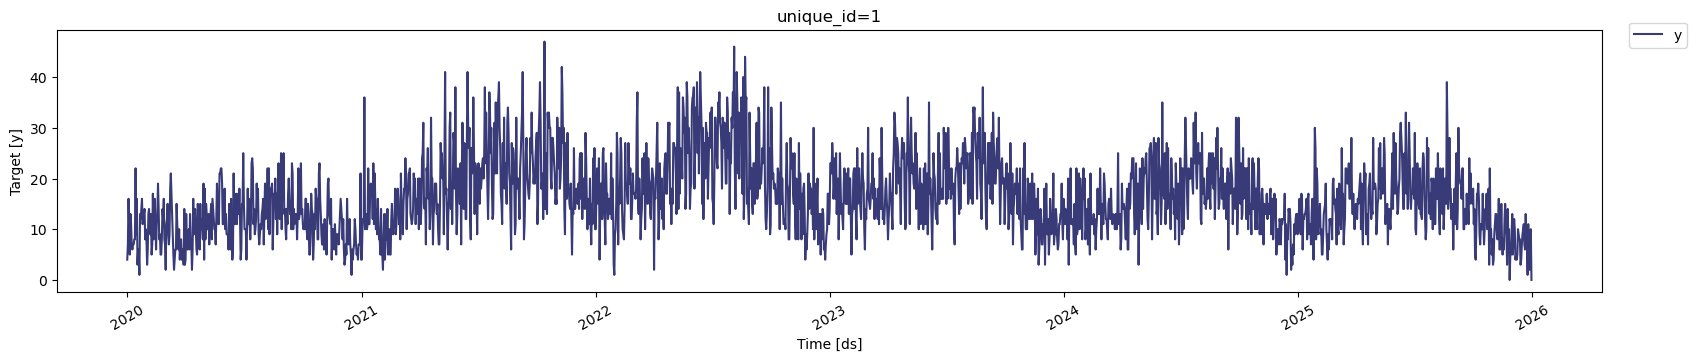

In [126]:
StatsForecast.plot(df)

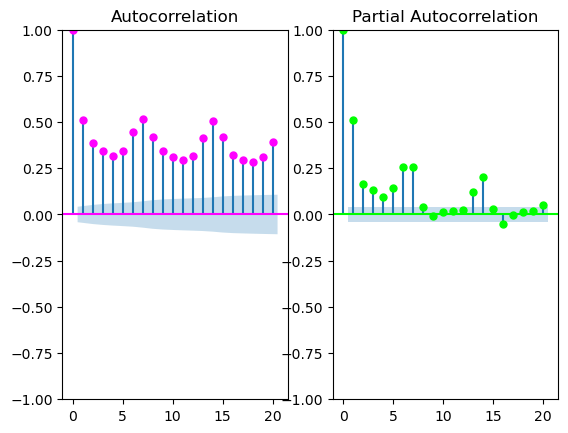

In [127]:
fig, axs = plt.subplots(nrows=1, ncols=2)

plot_acf(df["y"],  lags=20, ax=axs[0],color="fuchsia")
axs[0].set_title("Autocorrelation");

# Plot
plot_pacf(df["y"],  lags=20, ax=axs[1],color="lime")
axs[1].set_title('Partial Autocorrelation')

plt.show();

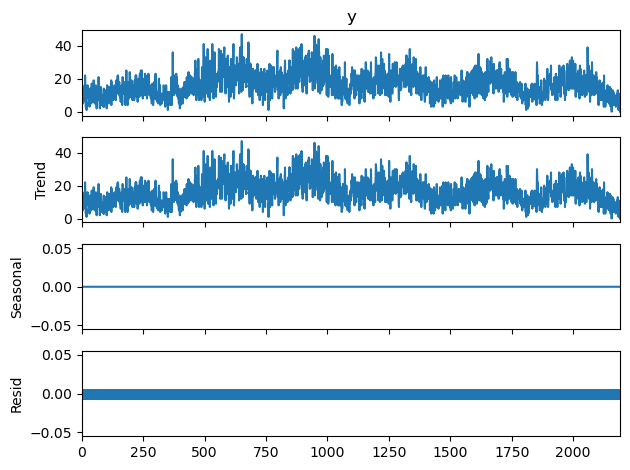

In [128]:
from statsmodels.tsa.seasonal import seasonal_decompose
a = seasonal_decompose(df["y"], model = "add", period=1)
a.plot();

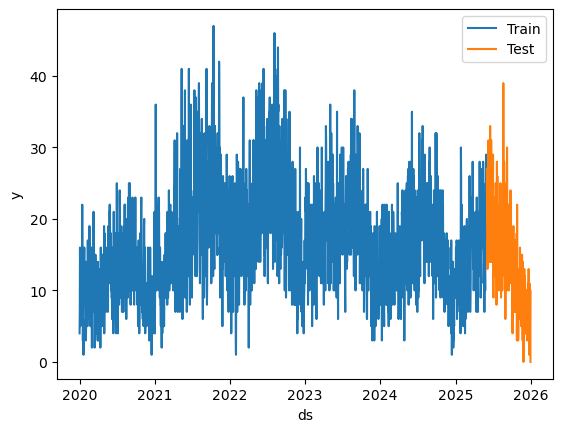

In [129]:
train = df[df.ds<='2025-06-01']
test = df[df.ds>'2025-06-01']

sns.lineplot(train,x="ds", y="y", label="Train")
sns.lineplot(test, x="ds", y="y", label="Test")
plt.show()

In [130]:
sf = StatsForecast(models=[AutoETS(model="AZN")], freq='D')

In [131]:
sf.fit(df=train)

StatsForecast(models=[AutoETS])

In [132]:
y_hat = sf.predict(h=213, level=[80,90,95])
y_hat

,unique_id,ds,AutoETS,AutoETS-lo-95,AutoETS-lo-90,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-90,AutoETS-hi-95
0,1,2025-06-02,17.541599,5.553189,7.480608,9.702799,25.380400,27.602591,29.530010
1,1,2025-06-03,17.541599,5.504521,7.439765,9.670977,25.412222,27.643433,29.578676
2,1,2025-06-04,17.541599,5.456050,7.399086,9.639283,25.443914,27.684113,29.627148
3,1,2025-06-05,17.541599,5.407772,7.358571,9.607717,25.475483,27.724628,29.675426
4,1,2025-06-06,17.541599,5.359686,7.318215,9.576274,25.506924,27.764982,29.723513
...,...,...,...,...,...,...,...,...,...
208,1,2025-12-27,17.541599,-2.128869,1.033622,4.679771,30.403427,34.049576,37.212067
209,1,2025-12-28,17.541599,-2.158568,1.008698,4.660352,30.422846,34.074501,37.241768
210,1,2025-12-29,17.541599,-2.188222,0.983811,4.640963,30.442236,34.099388,37.271420
211,1,2025-12-30,17.541599,-2.217831,0.958962,4.621602,30.461596,34.124237,37.301029


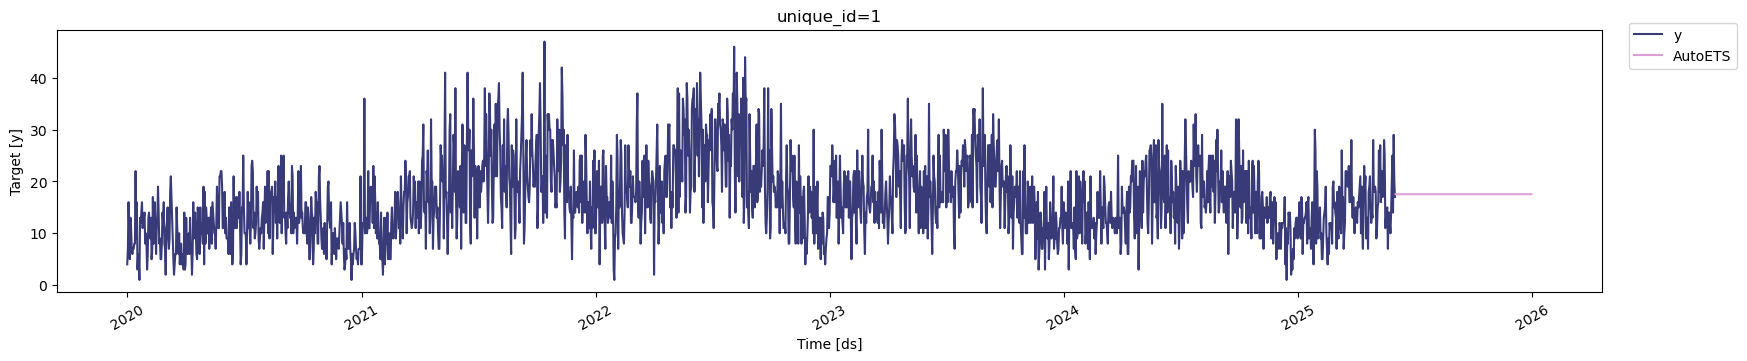

In [133]:
sf.plot(train, y_hat)

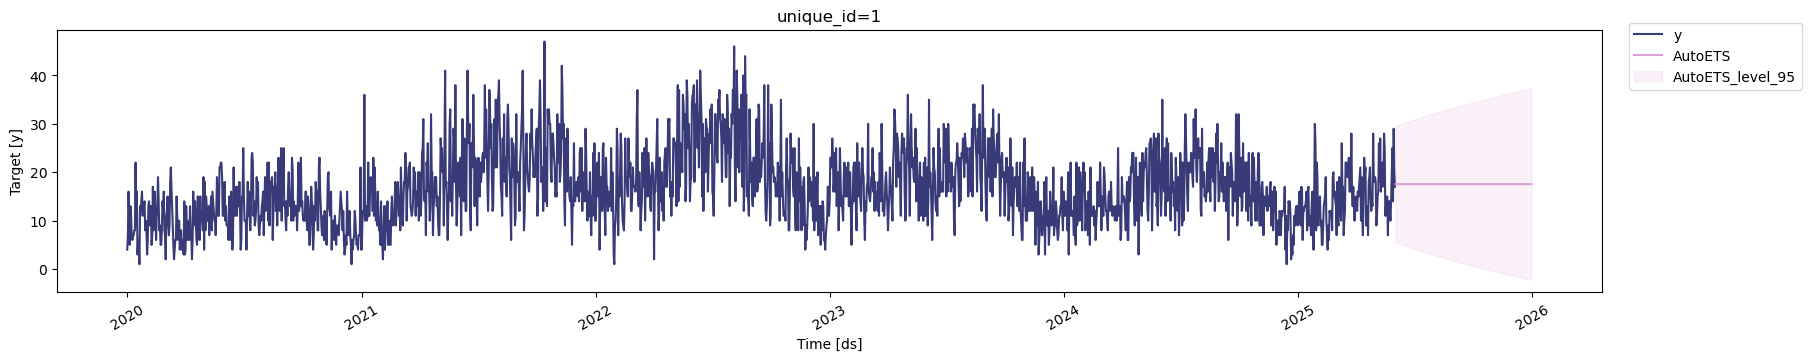

In [134]:
sf.plot(train, y_hat, level=[95])

In [135]:
y_hat = sf.forecast(df=train, h=213, fitted=True)
y_hat

,unique_id,ds,AutoETS
0,1,2025-06-02,17.541599
1,1,2025-06-03,17.541599
2,1,2025-06-04,17.541599
3,1,2025-06-05,17.541599
4,1,2025-06-06,17.541599
...,...,...,...
208,1,2025-12-27,17.541599
209,1,2025-12-28,17.541599
210,1,2025-12-29,17.541599
211,1,2025-12-30,17.541599


In [136]:
from functools import partial

import utilsforecast.losses as ufl
from utilsforecast.evaluation import evaluate

In [137]:
evaluate(
    y_hat.merge(test),
    metrics=[ufl.mae, ufl.mape, partial(ufl.mase, seasonality=1), ufl.rmse, ufl.smape],
    train_df=train,
)

,unique_id,metric,AutoETS
0,1,mae,6.419962
1,1,mape,0.825735
2,1,mase,1.105483
3,1,rmse,7.720843
4,1,smape,0.230176


## Holter-Winters forecasting with Cross Validation

In [138]:
horizon = 14

crossvalidation_df = sf.cross_validation(df=df,
                                         h=horizon,
                                         step_size=30,
                                         n_windows=30)

In [139]:
crossvalidation_df


,unique_id,ds,cutoff,y,AutoETS
0,1,2023-08-01,2023-07-31,26.0,21.417995
1,1,2023-08-02,2023-07-31,22.0,21.417995
2,1,2023-08-03,2023-07-31,24.0,21.417995
3,1,2023-08-04,2023-07-31,25.0,21.417995
4,1,2023-08-05,2023-07-31,15.0,21.417995
...,...,...,...,...,...
415,1,2025-12-27,2025-12-17,5.0,7.221093
416,1,2025-12-28,2025-12-17,2.0,7.221093
417,1,2025-12-29,2025-12-17,6.0,7.221093
418,1,2025-12-30,2025-12-17,10.0,7.221093


In [140]:
Y_hat = sf.forecast(df=train, h=horizon, fitted=True)

In [141]:
evaluate(
    test.merge(Y_hat),
    metrics=[ufl.mae, ufl.mape, partial(ufl.mase, seasonality=season_length), ufl.rmse, ufl.smape],
    train_df=train,
)

,unique_id,metric,AutoETS
0,1,mae,5.339315
1,1,mape,0.238087
2,1,mase,0.701421
3,1,rmse,6.760073
4,1,smape,0.130214


## CV with MSTL Model

In [142]:
h = 14                # forecast horizon 
step_size = 30        # cv_period (how many days to add on each step)
input_size = 730      # initial training size (730 days)

# Calculate n_windows automatically based on available data
total_days = len(df[df['unique_id'] == df['unique_id'].iloc[0]])  # length of your series
available_days = total_days - input_size - h  # data available after initial + first horizon
n_windows = max(1, math.floor(available_days / step_size) + 1)

In [143]:
from statsforecast import StatsForecast
from statsforecast.models import MSTL, AutoARIMA
import math


models = [MSTL(season_length=[7, 365], trend_forecaster=AutoARIMA())]

sf = StatsForecast(
    models=models,
    freq='D',
    n_jobs=-1
)

print(f"Automatically calculated n_windows: {n_windows}")

crossvalidation_df = sf.cross_validation(
    df=df,
    h=h,
    step_size=step_size,
    input_size=input_size,
    n_windows=n_windows,
)

Automatically calculated n_windows: 49


In [144]:
sf = sf.fit(df=df)

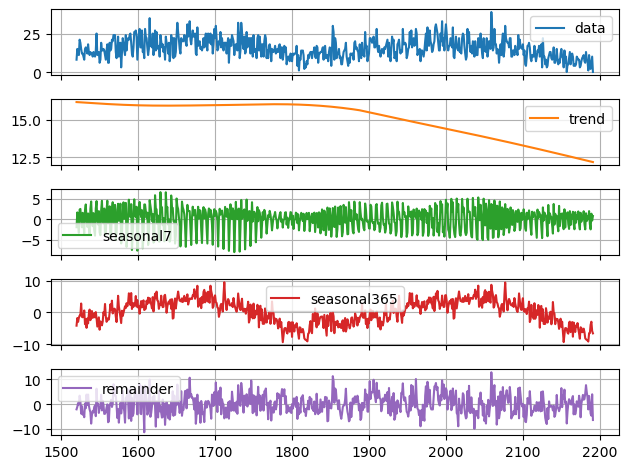

In [145]:
sf.fitted_[0, 0].model_.tail(24 * 28).plot(subplots=True, grid=True)
plt.tight_layout()
plt.show()

In [146]:
forecasts = sf.predict(h=24, level=[90])
forecasts.head()

,unique_id,ds,MSTL,MSTL-lo-90,MSTL-hi-90
0,1,2026-01-01,11.097243,4.096336,18.098150
1,1,2026-01-02,12.368555,5.232013,19.505096
2,1,2026-01-03,8.112494,0.853303,15.371686
3,1,2026-01-04,10.929538,3.608919,18.250156
4,1,2026-01-05,10.820977,3.465081,18.176874


In [147]:
from utilsforecast.losses import rmse
from utilsforecast.evaluation import evaluate

evaluate(
    crossvalidation_df.drop(columns='cutoff'),
    metrics=[rmse],
    agg_fn='mean',
)

,metric,MSTL
0,rmse,7.016332


In [148]:
from utilsforecast.losses import rmse

cv_rmse = rmse(crossvalidation_df, models=['MSTL'], target_col='y')
print(cv_rmse)

       cutoff  unique_id      MSTL
0  2022-01-07          1  8.933767
1  2022-02-06          1  6.208797
2  2022-03-08          1  9.173875
3  2022-04-07          1  6.700611
4  2022-05-07          1  8.597722
5  2022-06-06          1  8.440384
6  2022-07-06          1  5.235776
7  2022-08-05          1  8.764388
8  2022-09-04          1  8.764783
9  2022-10-04          1  8.774847
10 2022-11-03          1  9.141763
11 2022-12-03          1  5.222919
12 2023-01-02          1  6.189995
13 2023-02-01          1  5.769091
14 2023-03-03          1  6.297578
15 2023-04-02          1  8.117297
16 2023-05-02          1  7.454731
17 2023-06-01          1  7.300055
18 2023-07-01          1  8.444445
19 2023-07-31          1  7.976995
20 2023-08-30          1  9.007524
21 2023-09-29          1  6.566001
22 2023-10-29          1  6.047333
23 2023-11-28          1  6.967928
24 2023-12-28          1  6.459654
25 2024-01-27          1  6.731441
26 2024-02-26          1  5.638521
27 2024-03-27       

In [149]:
import numpy as np

# Add a horizon column (days ahead from cutoff)
crossvalidation_df['horizon'] = (crossvalidation_df['ds'] - crossvalidation_df['cutoff']).dt.days

# Compute metrics per horizon step
df_p = crossvalidation_df.groupby('horizon').apply(
    lambda x: pd.Series({
        'mse': ((x['y'] - x['MSTL']) ** 2).mean(),
        'rmse': np.sqrt(((x['y'] - x['MSTL']) ** 2).mean()),
        'mae': (x['y'] - x['MSTL']).abs().mean(),
        'mape': ((x['y'] - x['MSTL']).abs() / x['y']).mean(),
    })
).reset_index()

/var/folders/ry/m6r2ndwd10bdv8tvww5hr2680000gn/T/ipykernel_59966/1148771274.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_p = crossvalidation_df.groupby('horizon').apply(


In [150]:
df_p

,horizon,mse,rmse,mae,mape
0,1,61.971180,7.872178,5.991941,0.440371
1,2,45.989502,6.781556,5.108743,0.300429
2,3,43.894062,6.625259,5.459085,0.383391
3,4,59.098083,7.687528,6.285496,0.390148
4,5,53.550884,7.317847,6.167850,0.464163
5,6,48.603901,6.971650,5.233687,0.396871
6,7,47.284161,6.876348,5.584812,0.299658
7,8,43.632687,6.605504,5.269900,0.484827
8,9,58.359180,7.639318,6.452108,0.428927
9,10,47.960335,6.925340,5.169795,inf


The above table is more comparable to the table we get from prophet.